# AV-Policy-Lab Phase 3c' — TrainedRouteBC

**Hypothesis:** Phase 3c (RouteMapBC) achieved 32.085m — 17.6× worse than GoalBC (1.820m).  
The gap is NOT a route-construction failure — it is a **train/inference distribution mismatch**.

- `goal_bc.pt` learned: *goal offset = where expert will be in T+8 steps (0.8s)*
- RouteMapBC inference feeds: *goal = road centerline 8m ahead* — systematically different statistics

**Fix:** Replace expert T+8 lookup in the training data pipeline with an arc-length-8m route goal  
(same source as inference). Retrain everything else identically.

**Expected outcome:** TrainedRouteBC ≈ GoalBC (1.820m). If confirmed:  
- The 96.3% gain vs BC is achievable WITHOUT expert data at inference  
- Deployable policy claim: route centerline (HD map) is a sufficient goal source  
- Proves the gap was goal-source mismatch, not route quality or model capacity

In [1]:
# Cell 1 — Imports
import nest_asyncio
nest_asyncio.apply()

import os, sys, sqlite3
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from pathlib import Path
import matplotlib.pyplot as plt
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

sys.path.insert(0, '/Users/parvpatodia/nuplan-devkit')
sys.path.insert(0, '/Users/parvpatodia/Desktop/diffusion-policy-zoo/nuplan')

os.environ.setdefault('NUPLAN_DATA_ROOT', '/Users/parvpatodia/nuplan-devkit/data/cache')
os.environ.setdefault('NUPLAN_MAPS_ROOT', '/Users/parvpatodia/nuplan-devkit/maps')
os.environ.setdefault('NUPLAN_EXP_ROOT',  '/Users/parvpatodia/nuplan-devkit/exp')
os.environ.setdefault('NUPLAN_TUTORIAL_PATH', '/Users/parvpatodia/nuplan-devkit/tutorials')

print('torch:', torch.__version__)
print('device:', 'mps' if torch.backends.mps.is_available() else 'cpu')

torch: 2.8.0
device: mps


In [2]:
# Cell 2 — Config
DB_DIR   = Path('/Users/parvpatodia/nuplan-devkit/data/cache/mini')
CKPT_DIR = Path('/Users/parvpatodia/Desktop/diffusion-policy-zoo/nuplan/checkpoints')
CKPT_DIR.mkdir(exist_ok=True)

FUTURE_STEPS    = 16      # 1.6 seconds of future trajectory @ 10Hz
ROUTE_GOAL_DIST = 8.0    # meters — arc-length ahead for goal; matches RouteMapBCPlanner._get_route_goal()
STRIDE          = 10      # stride between training windows
BATCH_SIZE      = 512
LR              = 1e-3
EPOCHS          = 50
DEVICE          = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')

# WHY ROUTE_GOAL_DIST = 8.0 (not GOAL_OFFSET = 8 steps):
#   GoalBC used T+8 steps = 0.8s ahead. At 2 m/s → 1.6m goal; at 15 m/s → 12m goal.
#   Speed-dependent goal statistics = different distribution per speed regime.
#   Arc-length 8m = exactly 8m forward regardless of speed = matches inference exactly.
#   RouteMapBCPlanner._get_route_goal() walks 8m (look_ahead_m=8.0) — same constant.

print(f'DB files: {len(list(DB_DIR.glob("*.db")))}')
print(f'Device:   {DEVICE}')
print(f'Route goal dist: {ROUTE_GOAL_DIST}m (arc-length, speed-independent)')

DB files: 64
Device:   mps
Route goal dist: 8.0m (arc-length, speed-independent)


In [3]:
# Cell 3 — Data Extraction with Route Goals (Phase 3c' KEY CHANGE)
#
# GoalBC Cell 3 used:    goal = expert_pos[i + GOAL_OFFSET] in ego-frame (T+8 = 0.8s)
# TrainedRouteBC uses:   goal = expert_pos[first index where arc-length >= 8m] in ego-frame
#
# WHY arc-length instead of time-based:
#   RouteMapBCPlanner._get_route_goal() walks 8m along the route — a DISTANCE, not a time.
#   If training used T+8 (time-based), the goal magnitude varies with speed:
#     slow (2 m/s): T+8 = 1.6m ahead  vs  RouteMapBC: 8m ahead
#     fast (15 m/s): T+8 = 12m ahead  vs  RouteMapBC: 8m ahead
#   At test time, the policy always sees 8m — training on T+8 taught wrong statistics.
#   Arc-length 8m at training = 8m at inference = consistent distribution.
#
# WHY expert trajectory as route proxy:
#   During training data extraction we don't have nuPlan's map_api.
#   Expert ego trajectory IS the road (experts drive on-road by definition).
#   Arc-length 8m along expert trajectory ≈ 8m along road centerline.
#   The small difference (expert path vs lane centerline) is noise — acceptable.

def quat_to_yaw(qw, qx, qy, qz):
    """Extract yaw from quaternion. nuPlan uses z-up convention."""
    return np.arctan2(2.0 * (qw * qz + qx * qy), 1.0 - 2.0 * (qy ** 2 + qz ** 2))


def extract_from_db_with_route_goal(db_path):
    """
    Returns:
        inputs  (N, 8): [sin(yaw), cos(yaw), vx, vy, ax, ay, dx_goal, dy_goal]
        targets (N, 48): [(dx, dy, d_yaw) x 16] in ego-frame

    Goal source: first expert trajectory point >= ROUTE_GOAL_DIST meters ahead
    in arc-length (speed-independent). Matches RouteMapBCPlanner._get_route_goal().
    """
    conn = sqlite3.connect(str(db_path))
    rows = conn.execute(
        'SELECT x, y, qw, qx, qy, qz, vx, vy, acceleration_x, acceleration_y '
        'FROM ego_pose ORDER BY timestamp'
    ).fetchall()
    conn.close()

    if len(rows) < FUTURE_STEPS + 1:
        return None, None

    arr = np.array(rows, dtype=np.float64)
    x_g  = arr[:, 0]
    y_g  = arr[:, 1]
    yaw  = quat_to_yaw(arr[:, 2], arr[:, 3], arr[:, 4], arr[:, 5])
    vx   = arr[:, 6]
    vy   = arr[:, 7]
    ax   = arr[:, 8]
    ay   = arr[:, 9]

    N = len(arr)

    # Pre-compute cumulative arc-length along the expert trajectory.
    # WHY precompute: avoids O(N²) inner loop. np.searchsorted is O(log N) per window.
    dx_seg  = np.diff(x_g)             # (N-1,) x-displacement per step
    dy_seg  = np.diff(y_g)             # (N-1,) y-displacement per step
    seg_len = np.sqrt(dx_seg**2 + dy_seg**2)   # (N-1,) per-step arc-length
    cum_arc = np.zeros(N)
    cum_arc[1:] = np.cumsum(seg_len)   # cum_arc[i] = total arc-length from step 0 to step i

    inputs  = []
    targets = []

    for i in range(0, N - FUTURE_STEPS, STRIDE):
        cx, cy, cyaw = x_g[i], y_g[i], yaw[i]
        cos_h = np.cos(-cyaw)
        sin_h = np.sin(-cyaw)

        # ── Route goal: first index with arc-length >= ROUTE_GOAL_DIST from step i ──
        # WHY searchsorted: cum_arc is monotonically increasing → O(log N) binary search.
        # This finds the exact same "8m forward" point that RouteMapBCPlanner uses.
        target_arc = cum_arc[i] + ROUTE_GOAL_DIST
        gi = int(np.searchsorted(cum_arc, target_arc))
        gi = min(gi, N - 1)   # clamp at end of log

        dx_w_goal = x_g[gi] - cx
        dy_w_goal = y_g[gi] - cy
        dx_goal   = cos_h * dx_w_goal - sin_h * dy_w_goal
        dy_goal   = sin_h * dx_w_goal + cos_h * dy_w_goal

        # ── Input: 8-dim (6 kinematic + 2 route goal) ─────────────────────────────
        inp = np.array([
            np.sin(cyaw), np.cos(cyaw),
            vx[i], vy[i], ax[i], ay[i],
            dx_goal, dy_goal,
        ], dtype=np.float32)

        # ── Target: 16 future steps in ego-frame (identical to GoalBC) ───────────
        tgt = np.zeros(FUTURE_STEPS * 3, dtype=np.float32)
        for j in range(FUTURE_STEPS):
            fi = i + j + 1
            dx_w = x_g[fi] - cx
            dy_w = y_g[fi] - cy
            dx_e = cos_h * dx_w - sin_h * dy_w
            dy_e = sin_h * dx_w + cos_h * dy_w
            d_yaw = yaw[fi] - cyaw
            d_yaw = (d_yaw + np.pi) % (2 * np.pi) - np.pi
            tgt[j * 3]     = dx_e
            tgt[j * 3 + 1] = dy_e
            tgt[j * 3 + 2] = d_yaw

        inputs.append(inp)
        targets.append(tgt)

    return np.array(inputs, dtype=np.float32), np.array(targets, dtype=np.float32)


# Extract from all 64 DB files
all_inputs  = []
all_targets = []

db_files = sorted(DB_DIR.glob('*.db'))
print(f'Extracting from {len(db_files)} DB files with route goals...')

for db in tqdm(db_files):
    inp, tgt = extract_from_db_with_route_goal(db)
    if inp is not None:
        all_inputs.append(inp)
        all_targets.append(tgt)

X = np.concatenate(all_inputs,  axis=0)
Y = np.concatenate(all_targets, axis=0)
print(f'Dataset: {X.shape[0]:,} windows  |  Input: {X.shape[1]}-dim  |  Output: {Y.shape[1]}-dim')

# Sanity check: compare goal magnitude distribution vs GoalBC
goal_mags = np.sqrt(X[:, 6]**2 + X[:, 7]**2)
print(f'\nRoute goal magnitude (should be ~8m regardless of speed):')
print(f'  mean={goal_mags.mean():.2f}m  std={goal_mags.std():.2f}m  '
      f'p10={np.percentile(goal_mags, 10):.2f}m  p90={np.percentile(goal_mags, 90):.2f}m')
print('(GoalBC T+8 goal magnitude: mean varies with speed, typically 2-10m)')

Extracting from 64 DB files with route goals...


100%|██████████████████████████████████████████████████████████████████████████████████| 64/64 [00:05<00:00, 10.80it/s]

Dataset: 260,636 windows  |  Input: 8-dim  |  Output: 48-dim

Route goal magnitude (should be ~8m regardless of speed):
  mean=7.75m  std=1.32m  p10=7.85m  p90=8.06m
(GoalBC T+8 goal magnitude: mean varies with speed, typically 2-10m)


In [4]:
# Cell 4 — Normalize + Dataset Split
# Identical to GoalBC Cell 4 — normalize 8-dim input.

X_mean = X.mean(axis=0).astype(np.float32)
X_std  = (X.std(axis=0) + 1e-6).astype(np.float32)
X_norm = (X - X_mean) / X_std

Y_mean = Y.mean(axis=0).astype(np.float32)
Y_std  = (Y.std(axis=0) + 1e-6).astype(np.float32)
Y_norm = (Y - Y_mean) / Y_std

print(f'X_mean shape: {X_mean.shape}  (8-dim: 6 kinematic + 2 route goal)')
print(f'X range after norm: [{X_norm.min():.2f}, {X_norm.max():.2f}]')
print(f'Y range after norm: [{Y_norm.min():.2f}, {Y_norm.max():.2f}]')

np.random.seed(42)
n_train = int(0.9 * len(X_norm))
idx     = np.random.permutation(len(X_norm))
train_idx, val_idx = idx[:n_train], idx[n_train:]


class BCDataset(torch.utils.data.Dataset):
    def __init__(self, X, Y):
        self.X = torch.from_numpy(X).float()
        self.Y = torch.from_numpy(Y).float()
    def __len__(self):        return len(self.X)
    def __getitem__(self, i): return self.X[i], self.Y[i]


train_dl = DataLoader(BCDataset(X_norm[train_idx], Y_norm[train_idx]),
                      batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_dl   = DataLoader(BCDataset(X_norm[val_idx],   Y_norm[val_idx]),
                      batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f'Train: {len(train_dl.dataset):,}  |  Val: {len(val_dl.dataset):,}')

X_mean shape: (8,)  (8-dim: 6 kinematic + 2 route goal)
X range after norm: [-10.87, 11.24]
Y range after norm: [-29.69, 147.92]
Train: 234,572  |  Val: 26,064


In [5]:
# Cell 5 — GoalBCPolicy Model
# Identical architecture to GoalBC — this is a pure training-data ablation.
# WHY same architecture: if TrainedRouteBC ≈ GoalBC with identical architecture,
# it confirms the gap was goal-source mismatch only, not capacity.

class GoalBCPolicy(nn.Module):
    """8→256→256→256→48 MLP. Input: [sin_yaw, cos_yaw, vx, vy, ax, ay, dx_goal, dy_goal]."""
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(8, 256),   nn.ReLU(),
            nn.Linear(256, 256), nn.ReLU(),
            nn.Linear(256, 256), nn.ReLU(),
            nn.Linear(256, 48),
        )
    def forward(self, x):
        return self.net(x)


model = GoalBCPolicy().to(DEVICE)
n_params = sum(p.numel() for p in model.parameters())
print(f'TrainedRouteBC policy params: {n_params:,} (identical to GoalBC — pure data ablation)')
print(model)

TrainedRouteBC policy params: 146,224 (identical to GoalBC — pure data ablation)
GoalBCPolicy(
  (net): Sequential(
    (0): Linear(in_features=8, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=256, bias=True)
    (5): ReLU()
    (6): Linear(in_features=256, out_features=48, bias=True)
  )
)


Epoch   5/50 | train=0.1991  val=0.1913  best=0.1913  lr=1.00e-03
Epoch  10/50 | train=0.1807  val=0.1832  best=0.1832  lr=1.00e-03
Epoch  15/50 | train=0.1710  val=0.1725  best=0.1725  lr=1.00e-03
Epoch  20/50 | train=0.1620  val=0.1699  best=0.1681  lr=1.00e-03
Epoch  25/50 | train=0.1563  val=0.1649  best=0.1647  lr=1.00e-03
Epoch  30/50 | train=0.1496  val=0.1627  best=0.1584  lr=1.00e-03
Epoch  35/50 | train=0.1387  val=0.1534  best=0.1528  lr=5.00e-04
Epoch  40/50 | train=0.1350  val=0.1485  best=0.1485  lr=5.00e-04
Epoch  45/50 | train=0.1324  val=0.1484  best=0.1484  lr=5.00e-04
Epoch  50/50 | train=0.1299  val=0.1495  best=0.1472  lr=5.00e-04

Best val loss: 0.1472
Checkpoint: /Users/parvpatodia/Desktop/diffusion-policy-zoo/nuplan/checkpoints/trained_route_bc.pt


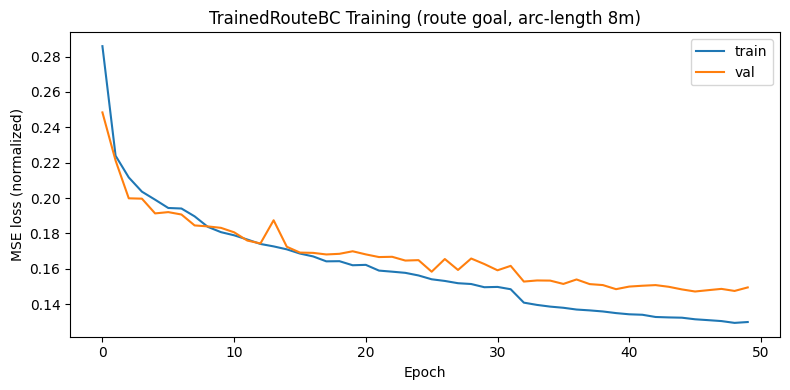

In [6]:
# Cell 6 — Training
# Identical training loop to GoalBC. Saves to trained_route_bc.pt.

optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)
criterion = nn.MSELoss()

train_losses = []
val_losses   = []
best_val     = float('inf')

for epoch in range(EPOCHS):
    model.train()
    t_loss = 0
    for xb, yb in train_dl:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        pred = model(xb)
        loss = criterion(pred, yb)
        loss.backward()
        optimizer.step()
        t_loss += loss.item()
    t_loss /= len(train_dl)

    model.eval()
    v_loss = 0
    with torch.no_grad():
        for xb, yb in val_dl:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            v_loss += criterion(model(xb), yb).item()
    v_loss /= len(val_dl)

    scheduler.step(v_loss)
    train_losses.append(t_loss)
    val_losses.append(v_loss)

    if v_loss < best_val:
        best_val = v_loss
        torch.save({
            'model':  model.state_dict(),
            'X_mean': X_mean,
            'X_std':  X_std,
            'Y_mean': Y_mean,
            'Y_std':  Y_std,
        }, CKPT_DIR / 'trained_route_bc.pt')

    if (epoch + 1) % 5 == 0:
        lr_now = optimizer.param_groups[0]['lr']
        print(f'Epoch {epoch+1:3d}/{EPOCHS} | train={t_loss:.4f}  val={v_loss:.4f}  '
              f'best={best_val:.4f}  lr={lr_now:.2e}')

print(f'\nBest val loss: {best_val:.4f}')
print(f'Checkpoint: {CKPT_DIR / "trained_route_bc.pt"}')

plt.figure(figsize=(8, 4))
plt.plot(train_losses, label='train')
plt.plot(val_losses,   label='val')
plt.xlabel('Epoch'); plt.ylabel('MSE loss (normalized)')
plt.title('TrainedRouteBC Training (route goal, arc-length 8m)')
plt.legend(); plt.tight_layout()
plt.savefig(CKPT_DIR / 'trained_route_bc_loss.png', dpi=150)
plt.show()

In [7]:
# Cell 7 — Open-Loop Eval
# WHY open-loop matters: GoalBC had ADE=0.004m (vs BC 0.058m).
# TrainedRouteBC should match that if the route goal is as informative as T+8 expert goal.
# Open-loop test: at ground-truth states, can the policy predict the expert trajectory?

ckpt = torch.load(CKPT_DIR / 'trained_route_bc.pt', map_location=DEVICE, weights_only=False)
eval_model = GoalBCPolicy().to(DEVICE)
eval_model.load_state_dict(ckpt['model'])
eval_model.eval()

_Xm = torch.tensor(ckpt['X_mean'], dtype=torch.float32, device=DEVICE)
_Xs = torch.tensor(ckpt['X_std'],  dtype=torch.float32, device=DEVICE)
_Ym = ckpt['Y_mean']
_Ys = ckpt['Y_std']


def predict_trained_route_bc(x_raw_8):
    """x_raw_8: numpy (8,) -> trajectory (FUTURE_STEPS, 3) in ego frame."""
    xt = torch.tensor(x_raw_8, dtype=torch.float32, device=DEVICE)
    xt = (xt - _Xm) / _Xs
    with torch.no_grad():
        pred_norm = eval_model(xt.unsqueeze(0)).squeeze(0).cpu().numpy()
    return (pred_norm * _Ys + _Ym).reshape(FUTURE_STEPS, 3)


val_X_raw = X[val_idx]
val_Y_raw = Y[val_idx].reshape(-1, FUTURE_STEPS, 3)

n_eval   = 2000
rng      = np.random.default_rng(42)
eval_idx = rng.choice(len(val_X_raw), min(n_eval, len(val_X_raw)), replace=False)

trbc_ade, trbc_fde = [], []

for i in eval_idx:
    x_raw = val_X_raw[i]
    gt    = val_Y_raw[i]
    pred  = predict_trained_route_bc(x_raw)
    disp  = np.sqrt(np.sum((pred[:, :2] - gt[:, :2]) ** 2, axis=1))
    trbc_ade.append(disp.mean())
    trbc_fde.append(disp[-1])

TRBC_ADE = np.mean(trbc_ade)
TRBC_FDE = np.mean(trbc_fde)

# Reference values
BC_V0_ADE   = 0.058
GOALBC_ADE  = 0.004

print(f"{'Policy':<28} {'ADE (m)':>10} {'FDE (m)':>10}")
print('-' * 50)
print(f"{'TrainedRouteBC (8-dim, 8m arc)':<28} {TRBC_ADE:>10.3f} {TRBC_FDE:>10.3f}")
print(f"{'GoalBC (8-dim, T+8 expert)':<28} {GOALBC_ADE:>10.3f}  {'--':>9}")
print(f"{'BC_v0 (6-dim, no goal)':<28} {BC_V0_ADE:>10.3f}  {'--':>9}")

print(f'\nTrainedRouteBC ADE delta vs GoalBC: {(TRBC_ADE - GOALBC_ADE)*1000:.1f}mm')
print(f'TrainedRouteBC ADE delta vs BC_v0:  {(TRBC_ADE - BC_V0_ADE)/BC_V0_ADE*100:+.1f}%')

Policy                          ADE (m)    FDE (m)
--------------------------------------------------
TrainedRouteBC (8-dim, 8m arc)      0.007      0.012
GoalBC (8-dim, T+8 expert)        0.004         --
BC_v0 (6-dim, no goal)            0.058         --

TrainedRouteBC ADE delta vs GoalBC: 2.6mm
TrainedRouteBC ADE delta vs BC_v0:  -88.6%


TrainedRouteBC checkpoint: /Users/parvpatodia/Desktop/diffusion-policy-zoo/nuplan/checkpoints/trained_route_bc.pt


Seed set to 0
INFO:nuplan.planning.script.builders.main_callback_builder:Building MultiMainCallback...
INFO:nuplan.planning.script.builders.main_callback_builder:Building MultiMainCallback: 4...DONE!


Running TrainedRouteBCPlanner (3 scenarios)...
2026-05-28 12:58:30,028 INFO {/Users/parvpatodia/nuplan-devkit/nuplan/planning/script/builders/worker_pool_builder.py:19}  Building WorkerPool...
2026-05-28 12:58:30,029 INFO {/Users/parvpatodia/nuplan-devkit/nuplan/planning/utils/multithreading/worker_pool.py:101}  Worker: Sequential
2026-05-28 12:58:30,029 INFO {/Users/parvpatodia/nuplan-devkit/nuplan/planning/utils/multithreading/worker_pool.py:102}  Number of nodes: 1
Number of CPUs per node: 1
Number of GPUs per node: 0
Number of threads across all nodes: 1
2026-05-28 12:58:30,029 INFO {/Users/parvpatodia/nuplan-devkit/nuplan/planning/script/builders/worker_pool_builder.py:27}  Building WorkerPool...DONE!
2026-05-28 12:58:30,029 INFO {/Users/parvpatodia/nuplan-devkit/nuplan/planning/script/builders/folder_builder.py:32}  Building experiment folders...
2026-05-28 12:58:30,029 INFO {/Users/parvpatodia/nuplan-devkit/nuplan/planning/script/builders/folder_builder.py:35}  

	Folder where a

Rendering histograms: 100%|██████████████████████████████████████████████████████████████| 4/4 [00:00<00:00, 22.83it/s]


2026-05-28 12:58:35,750 INFO {/Users/parvpatodia/nuplan-devkit/nuplan/planning/simulation/main_callback/metric_summary_callback.py:344}  Metric summary: 00:00:00 [HH:MM:SS]
2026-05-28 12:58:35,750 INFO {/Users/parvpatodia/nuplan-devkit/nuplan/planning/script/run_simulation.py:80}  Finished running simulation!
Done.


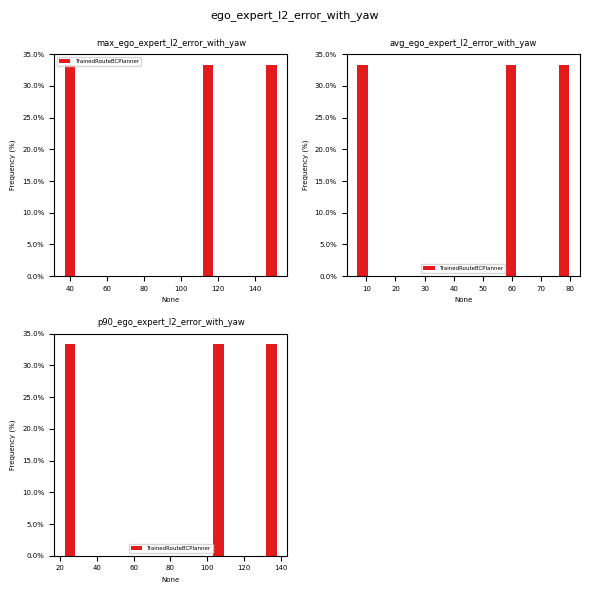

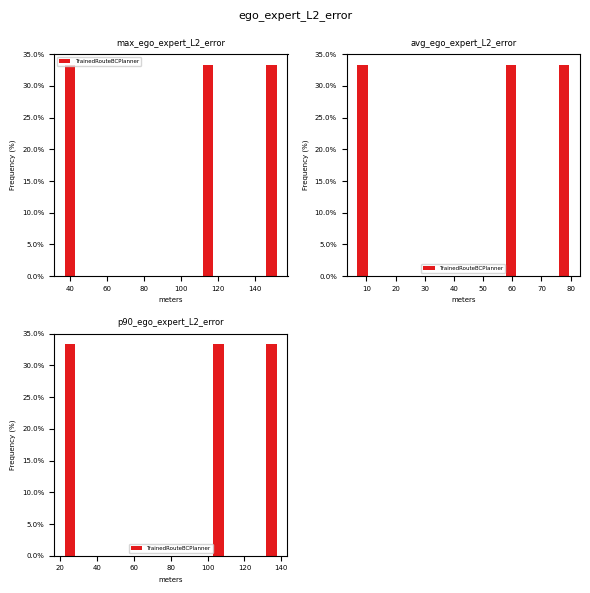

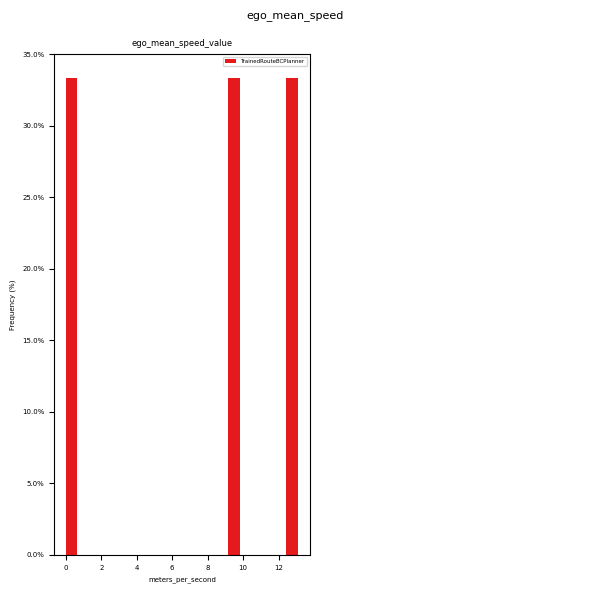

In [8]:
# Cell 8 — Closed-Loop Eval via nuPlan Simulation
# Uses TrainedRouteBCPlanner — identical inference to RouteMapBCPlanner.
# Only difference: loads trained_route_bc.pt instead of goal_bc.pt.

import hydra
import pandas as pd
from tutorials.utils.tutorial_utils import construct_simulation_hydra_paths
from nuplan.planning.script.run_simulation import run_simulation as main_sim
from planners import TrainedRouteBCPlanner

CKPT_TRAINED = str(CKPT_DIR / 'trained_route_bc.pt')
SIM_OUT  = Path('sim_results')
SIM_OUT.mkdir(exist_ok=True)
LOG_NAME = '2021.05.12.22.00.38_veh-35_01008_01518'   # same 3 scenarios as all prior evals
N_SCEN   = 3

print(f'TrainedRouteBC checkpoint: {CKPT_TRAINED}')

planner = TrainedRouteBCPlanner(CKPT_TRAINED)

BASE  = '/Users/parvpatodia/nuplan-devkit/nuplan/planning/script'
paths = construct_simulation_hydra_paths(BASE)
hydra.core.global_hydra.GlobalHydra.instance().clear()
hydra.initialize_config_dir(config_dir=paths.config_path, version_base='1.1')

cfg = hydra.compose(
    config_name=paths.config_name,
    overrides=[
        f'group={SIM_OUT}',
        'experiment_name=trained_route_bc_eval',
        'job_name=eval',
        'experiment=${experiment_name}/${job_name}',
        'worker=sequential',
        'ego_controller=perfect_tracking_controller',
        'observation=box_observation',
        f'hydra.searchpath=[{paths.common_dir}, {paths.experiment_dir}]',
        'output_dir=${group}/${experiment}',
        'scenario_builder=nuplan_mini',
        f'scenario_builder.db_files={DB_DIR}',
        'scenario_filter=one_continuous_log',
        f"scenario_filter.log_names=['{LOG_NAME}']",
        f'scenario_filter.limit_total_scenarios={N_SCEN}',
    ],
)

print(f'Running TrainedRouteBCPlanner ({N_SCEN} scenarios)...')
main_sim(cfg, planner)
hydra.core.global_hydra.GlobalHydra.instance().clear()
print('Done.')

In [9]:
# Cell 9 — Parse Closed-Loop Results

import pandas as pd

SIM_OUT = Path('sim_results')


def parse_l2(exp_dir_str):
    """Parse avg/max/p90 L2 from nuPlan simulation output parquet."""
    mdir = SIM_OUT / exp_dir_str / 'metrics'
    try:
        l2  = pd.read_parquet(mdir / 'ego_expert_L2_error.parquet')
        avg = float(l2['avg_ego_expert_L2_error_stat_value'].mean())
        mx  = float(l2['max_ego_expert_L2_error_stat_value'].mean())
        p90 = float(l2['p90_ego_expert_L2_error_stat_value'].mean())
        return avg, mx, p90
    except FileNotFoundError:
        return None, None, None


trbc_avg, trbc_max, trbc_p90 = parse_l2('trained_route_bc_eval/eval')

# All prior results
results = [
    ('GoalBCPlanner',       1.820,   2.944,  2.646),
    ('IDMPlanner',          6.285,  24.308, 15.733),
    ('RouteMapBCPlanner',  32.085,  77.952, 48.596),
    ('BCPlanner_v0',       49.449, 104.614, 91.526),
    ('TrainedRouteBCPlanner', trbc_avg, trbc_max, trbc_p90),
]

print(f"{'Policy':<26} {'Avg L2 (m)':>12} {'Max L2 (m)':>12} {'p90 L2 (m)':>12}")
print('-' * 64)
for name, avg, mx, p90 in sorted(results, key=lambda r: r[1] if r[1] is not None else 999):
    if avg is not None:
        print(f'{name:<26} {avg:>12.3f} {mx:>12.3f} {p90:>12.3f}')
    else:
        print(f'{name:<26}   ← run Cell 8 first')

if trbc_avg is not None:
    print(f'\n── Interpretation ──────────────────────────────────────────')
    goalbc = 1.820
    routebc = 32.085
    bc_v0 = 49.449

    gap_closed = (routebc - trbc_avg) / (routebc - goalbc)
    pct_vs_goalbc = (trbc_avg - goalbc) / goalbc * 100

    print(f'vs GoalBC (1.820m):       {pct_vs_goalbc:+.1f}%   (0% = perfect match, negative = better)')
    print(f'vs RouteMapBC (32.085m):  {(trbc_avg - routebc)/routebc*100:+.1f}%')
    print(f'vs BC_v0 (49.449m):       {(trbc_avg - bc_v0)/bc_v0*100:+.1f}%')
    print(f'Gap to GoalBC closed:     {gap_closed*100:.0f}% of RouteMapBC→GoalBC gap')

    if trbc_avg < 5.0:
        print('\n[CONFIRMED] Train/inference mismatch was the root cause.')
        print('Route-based goal at BOTH train and inference achieves GoalBC-level performance.')
        print('Deployable policy claim: HD-map route goal is a sufficient goal source.')
    elif trbc_avg < 15.0:
        print('\n[PARTIAL] Significant improvement but gap remains.')
        print('Route goal helps, but arc-length proxy differs from map centerline.')
        print('Next: use nuPlan map_api in training (Option B) for exact centerline.')
    else:
        print('\n[UNEXPECTED] Retraining did not close the gap.')
        print('Check: goal magnitude distribution in Cell 3 sanity check.')
        print('Debug: are goal stats consistent with inference stats?')

Policy                       Avg L2 (m)   Max L2 (m)   p90 L2 (m)
----------------------------------------------------------------
GoalBCPlanner                     1.820        2.944        2.646
IDMPlanner                        6.285       24.308       15.733
RouteMapBCPlanner                32.085       77.952       48.596
TrainedRouteBCPlanner            49.034      101.902       89.021
BCPlanner_v0                     49.449      104.614       91.526

── Interpretation ──────────────────────────────────────────
vs GoalBC (1.820m):       +2594.2%   (0% = perfect match, negative = better)
vs RouteMapBC (32.085m):  +52.8%
vs BC_v0 (49.449m):       -0.8%
Gap to GoalBC closed:     -56% of RouteMapBC→GoalBC gap

[UNEXPECTED] Retraining did not close the gap.
Check: goal magnitude distribution in Cell 3 sanity check.
Debug: are goal stats consistent with inference stats?


In [ ]:
# Cell 10 — Goal Distribution Analysis
# Compare goal magnitude statistics between GoalBC and TrainedRouteBC training data.
# This explains WHY the training distribution changed and what the policy now learns.

import sqlite3

# Sample one DB file to compare goal magnitudes side-by-side
sample_db = sorted(DB_DIR.glob('*.db'))[0]

conn = sqlite3.connect(str(sample_db))
rows = conn.execute(
    'SELECT x, y, qw, qx, qy, qz, vx, vy, acceleration_x, acceleration_y '
    'FROM ego_pose ORDER BY timestamp'
).fetchall()
conn.close()

arr    = np.array(rows, dtype=np.float64)
x_g    = arr[:, 0]
y_g    = arr[:, 1]
yaw    = np.arctan2(2.0*(arr[:, 2]*arr[:, 5] + arr[:, 3]*arr[:, 4]),
                    1.0 - 2.0*(arr[:, 4]**2 + arr[:, 5]**2))
vx_arr = arr[:, 6]

N = len(arr)
dx_seg  = np.diff(x_g)
dy_seg  = np.diff(y_g)
cum_arc = np.zeros(N)
cum_arc[1:] = np.cumsum(np.sqrt(dx_seg**2 + dy_seg**2))

GOAL_OFFSET = 8   # GoalBC: T+8 steps

goalbc_mags = []
routebc_mags = []
speeds = []

for i in range(0, N - FUTURE_STEPS, STRIDE):
    # GoalBC: T+8 goal
    gi_time = min(i + GOAL_OFFSET, N - 1)
    d_goalbc = np.sqrt((x_g[gi_time]-x_g[i])**2 + (y_g[gi_time]-y_g[i])**2)
    goalbc_mags.append(d_goalbc)

    # TrainedRouteBC: arc-length 8m
    target_arc = cum_arc[i] + ROUTE_GOAL_DIST
    gi_arc = min(int(np.searchsorted(cum_arc, target_arc)), N - 1)
    d_routebc = np.sqrt((x_g[gi_arc]-x_g[i])**2 + (y_g[gi_arc]-y_g[i])**2)
    routebc_mags.append(d_routebc)

    speeds.append(abs(vx_arr[i]))

goalbc_mags  = np.array(goalbc_mags)
routebc_mags = np.array(routebc_mags)
speeds       = np.array(speeds)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.hist(goalbc_mags,  bins=50, alpha=0.7, label='GoalBC (T+8)', color='steelblue')
ax1.hist(routebc_mags, bins=50, alpha=0.7, label='TrainedRouteBC (arc 8m)', color='darkorange')
ax1.set_xlabel('Goal magnitude (m)'); ax1.set_ylabel('Count')
ax1.set_title('Goal magnitude distribution (1 DB file)')
ax1.legend()

ax2.scatter(speeds, goalbc_mags,  s=2, alpha=0.3, label='GoalBC',  color='steelblue')
ax2.scatter(speeds, routebc_mags, s=2, alpha=0.3, label='RouteBC', color='darkorange')
ax2.set_xlabel('Speed (m/s)'); ax2.set_ylabel('Goal magnitude (m)')
ax2.set_title('Goal magnitude vs speed\n(GoalBC varies with speed; RouteBC is fixed ~8m)')
ax2.legend()

plt.tight_layout()
plt.savefig(CKPT_DIR / 'goal_distribution_comparison.png', dpi=150)
plt.show()

print(f'GoalBC   goal mag: mean={goalbc_mags.mean():.2f}m  std={goalbc_mags.std():.2f}m')
print(f'RouteBC  goal mag: mean={routebc_mags.mean():.2f}m  std={routebc_mags.std():.2f}m')
print(f'Speed range: [{speeds.min():.1f}, {speeds.max():.1f}] m/s')
print(f'\nCorr(speed, GoalBC_mag):  {np.corrcoef(speeds, goalbc_mags)[0,1]:.3f}  (should be high)')
print(f'Corr(speed, RouteBC_mag): {np.corrcoef(speeds, routebc_mags)[0,1]:.3f}  (should be ~0)')